In [3]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2

In [4]:
df = pd.read_csv(r"D:\GitHubRepos\is6400-business-data-analytics\data\further_cleaned_dataset.csv")
df.head(10)

,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags,Age,Miles_per_year,Brand_Model
0,13328,1399.0,LEXUS,RX 450,2010,Jeep,1,Hybrid,3.5,186005,6,Automatic,4x4,4,Left wheel,Silver,12,15,12400.333333,LEXUS_RX 450
1,16621,1018.0,CHEVROLET,Equinox,2011,Jeep,0,Petrol,3.0,192000,6,Tiptronic,4x4,4,Left wheel,Black,8,14,13714.285714,CHEVROLET_Equinox
2,8467,NaN,HONDA,FIT,2006,Hatchback,0,Petrol,1.3,200000,4,Variator,Front,4,Right-hand drive,Black,2,19,10526.315789,HONDA_FIT
3,3607,862.0,FORD,Escape,2011,Jeep,1,Hybrid,2.5,168966,4,Automatic,4x4,4,Left wheel,White,0,14,12069.000000,FORD_Escape
4,11726,446.0,HONDA,FIT,2014,Hatchback,1,Petrol,1.3,91901,4,Automatic,Front,4,Left wheel,Silver,4,11,8354.636364,HONDA_FIT
5,39493,891.0,HYUNDAI,Santa FE,2016,Jeep,1,Diesel,2.0,160931,4,Automatic,Front,4,Left wheel,White,4,9,17881.222222,HYUNDAI_Santa FE
6,1803,761.0,TOYOTA,Prius,2010,Hatchback,1,Hybrid,1.8,258909,4,Automatic,Front,4,Left wheel,White,12,15,17260.600000,TOYOTA_Prius
7,549,751.0,HYUNDAI,Sonata,2013,Sedan,1,Petrol,2.4,216118,4,Automatic,Front,4,Left wheel,Grey,12,12,18009.833333,HYUNDAI_Sonata
8,1098,394.0,TOYOTA,Camry,2014,Sedan,1,Hybrid,2.5,398069,4,Automatic,Front,4,Left wheel,Black,12,11,36188.090909,TOYOTA_Camry
9,26657,NaN,LEXUS,RX 350,2007,Jeep,1,Petrol,3.5,128500,6,Automatic,4x4,4,Left wheel,Silver,12,18,7138.888889,LEXUS_RX 350


In [5]:
# 数据预处理函数
def preprocess_data(df):
    # 处理缺失值
    df['Levy'] = df['Levy'].fillna(df['Levy'].median())
    
    # 对数变换长尾分布特征
    df['Mileage_log'] = np.log1p(df['Mileage'])
    df['Engine_vol_log'] = np.log1p(df['Engine volume'])
    df = df[df['Price'] < 1e6]
    # 时间敏感特征
    df['Depreciation'] = (2024 - df['Prod. year']) * df['Mileage'] / 1e5
    # 品牌溢价编码
    brand_prestige = {'LEXUS': 5, 'MERCEDES-BENZ': 4, 'BMW': 4, 'TOYOTA': 3}
    df['Brand_Score'] = df['Manufacturer'].map(brand_prestige).fillna(2)
    
    return df

In [6]:
df = preprocess_data(df)

In [7]:
# 定义特征和目标变量
X = df.drop(['Price', 'Mileage', 'Engine volume'], axis=1)  # 移除原始数值特征
y = np.log1p(df['Price'])  # 对数变换目标变量

In [8]:
# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
# 特征预处理管道
numeric_features = ['Levy', 'Prod. year', 'Cylinders', 'Airbags', 'Age', 'Miles_per_year']
numeric_transformer = Pipeline([
    ('scaler', StandardScaler())
])
categorical_features = ['Manufacturer', 'Category', 'Fuel type', 'Gear box type', 'Drive wheels']
categorical_transformer = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore', max_categories=50))
])

In [10]:
from tensorflow.keras.initializers import HeNormal
from tensorflow.keras.regularizers import l1_l2
from tensorflow.keras.optimizers import Nadam
from tensorflow.keras.layers import LeakyReLU, PReLU
from tensorflow.keras.callbacks import LearningRateScheduler
from tensorflow.keras.layers import Input, Add

# 构建MLP模型
# def build_mlp(input_dim):
#     init = HeNormal(seed=42)
#     reg = l1_l2(l1=1e-5, l2=1e-4)
    
#     # 使用函数式API构建残差连接
#     input_tensor = Input(shape=(input_dim,))
    
#     # 输入分支
#     x = Dense(512, kernel_initializer=init, kernel_regularizer=reg)(input_tensor)
#     x = BatchNormalization()(x)
#     x = LeakyReLU(alpha=0.1)(x)
#     x = Dropout(0.3)(x)
    
#     # 残差块
#     residual = x
#     x = Dense(256, kernel_regularizer=reg)(x)
#     x = BatchNormalization()(x)
#     x = PReLU()(x)
#     x = Dropout(0.2)(x)
#     x = Dense(512)(x)
#     x = Add()([residual, x])  # 正确使用Add层
    
#     # 后续层保持原样
#     x = Dense(64, activation='selu', kernel_initializer='lecun_normal')(x)
#     outputs = Dense(1, activation='linear')(x)
    
#     model = tf.keras.Model(inputs=input_tensor, outputs=outputs)
    
#     # 混合损失函数
#     def hybrid_loss(y_true, y_pred):
#         mae = tf.keras.losses.MAE(y_true, y_pred)
#         mse = tf.keras.losses.MSE(y_true, y_pred)
#         return 0.7*mae + 0.3*mse
    
#     # 自定义R²指标
#     class R2Score(tf.keras.metrics.Metric):
#         def __init__(self, name='r2', **kwargs):
#             super().__init__(name=name, **kwargs)
#             self.ss_res = self.add_weight(name='ss_res', initializer='zeros')
#             self.ss_tot = self.add_weight(name='ss_tot', initializer='zeros')

#         def update_state(self, y_true, y_pred, sample_weight=None):
#             y_true = tf.cast(y_true, tf.float32)
#             y_pred = tf.cast(y_pred, tf.float32)
#             ss_res = tf.reduce_sum(tf.square(y_true - y_pred))
#             ss_tot = tf.reduce_sum(tf.square(y_true - tf.reduce_mean(y_true)))
#             self.ss_res.assign_add(ss_res)
#             self.ss_tot.assign_add(ss_tot)

#         def result(self):
#             return 1 - self.ss_res / (self.ss_tot + tf.keras.backend.epsilon())

#     # 模型编译
#     model.compile(
#         optimizer=Nadam(learning_rate=0.001, clipvalue=0.5),
#         loss=hybrid_loss,
#         metrics=[R2Score(), 'mae']
#     )
    
#     return model

def build_mlp(input_dim):
    init = tf.keras.initializers.HeNormal(seed=42)
    reg = tf.keras.regularizers.l1_l2(l1=1e-5, l2=1e-4)
    
    # 输入层
    input_tensor = tf.keras.layers.Input(shape=(input_dim,))
    
    # 初始特征提取
    x = tf.keras.layers.Dense(512, kernel_initializer=init, kernel_regularizer=reg)(input_tensor)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.LeakyReLU(alpha=0.1)(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    
    # 残差块
    residual = x
    x = tf.keras.layers.Dense(256, kernel_regularizer=reg)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.PReLU()(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    x = tf.keras.layers.Dense(512)(x)
    x = tf.keras.layers.Add()([residual, x])
    
    # 特征注意力机制
    def feature_attention(inputs):
        """ 结构化数据特征注意力 """
        # 生成注意力分数 [batch_size, features]
        attn_scores = tf.keras.layers.Dense(
            inputs.shape[-1],  # 保持与特征维度一致
            activation='sigmoid',  # 使用sigmoid替代softmax允许特征多激活
            kernel_initializer='glorot_normal'
        )(inputs)
        
        # 应用注意力加权 [batch_size, features]
        weighted_features = tf.keras.layers.Multiply()([inputs, attn_scores])
        
        # 残差连接
        return tf.keras.layers.Add()([inputs, weighted_features])
    
    x = feature_attention(x)

    # 混合损失函数
    def hybrid_loss(y_true, y_pred):
        mae = tf.keras.losses.MAE(y_true, y_pred)
        mse = tf.keras.losses.MSE(y_true, y_pred)
        return 0.7*mae + 0.3*mse
    
    # 后续处理
    x = tf.keras.layers.Dense(64, activation='selu', kernel_initializer='lecun_normal')(x)
    outputs = tf.keras.layers.Dense(1, activation='linear')(x)
    
    # 构建模型
    model = tf.keras.Model(inputs=input_tensor, outputs=outputs)

    # 自定义R²指标
    class R2Score(tf.keras.metrics.Metric):
        def __init__(self, name='r2', **kwargs):
            super().__init__(name=name, **kwargs)
            self.ss_res = self.add_weight(name='ss_res', initializer='zeros')
            self.ss_tot = self.add_weight(name='ss_tot', initializer='zeros')

        def update_state(self, y_true, y_pred, sample_weight=None):
            y_true = tf.cast(y_true, tf.float32)
            y_pred = tf.cast(y_pred, tf.float32)
            ss_res = tf.reduce_sum(tf.square(y_true - y_pred))
            ss_tot = tf.reduce_sum(tf.square(y_true - tf.reduce_mean(y_true)))
            self.ss_res.assign_add(ss_res)
            self.ss_tot.assign_add(ss_tot)

        def result(self):
            return 1 - self.ss_res / (self.ss_tot + tf.keras.backend.epsilon())
    
    # 编译配置（保持原有损失函数和指标）
    model.compile(
        optimizer=tf.keras.optimizers.Nadam(learning_rate=0.001, clipvalue=0.5),
        loss=hybrid_loss,
        metrics=[R2Score(), 'mae']
    )
    
    return model

In [11]:
# 数据预处理
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', max_categories=50), categorical_features)
])

In [12]:
# 数据预处理
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [13]:
# 获取预处理后的特征维度
input_dim = X_train_processed.shape[1]

In [14]:
# 初始化模型
mlp = build_mlp(input_dim)

c:\Users\wjw20\miniconda3\envs\IS6400\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


In [15]:
# 添加学习率调度函数（在调用 fit() 之前）
def lr_schedule(epoch):
    """ 动态调整学习率 """
    base_lr = 0.001
    decay_rate = 0.9
    return base_lr * (decay_rate ** (epoch // 10))  # 每10个epoch衰减一次

In [16]:
# 训练模型
history = mlp.fit(
    X_train_processed.astype('float32'), 
    y_train.values.astype('float32'),
    validation_split=0.2,
    epochs=120,
    batch_size=128,
    callbacks=[
        LearningRateScheduler(lr_schedule),
        tf.keras.callbacks.TensorBoard(log_dir='./logs'),
        tf.keras.callbacks.ModelCheckpoint('best_model.h5', save_best_only=True)
    ],
)

Epoch 1/120
73/74 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.3224 - mae: 1.9555 - r2: -504.7751

74/74 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 4.2699 - mae: 1.9390 - r2: -498.2767 - val_loss: 3.4143 - val_mae: 2.1611 - val_r2: -319.0124 - learning_rate: 0.0010
Epoch 2/120
71/74 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.4937 - mae: 0.9646 - r2: -183.3812

74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.4931 - mae: 0.9642 - r2: -183.4216 - val_loss: 2.2783 - val_mae: 1.5770 - val_r2: -231.4611 - learning_rate: 0.0010
Epoch 3/120
66/74 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.4142 - mae: 0.9137 - r2: -181.9149

74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.4140 - mae: 0.9133 - r2: -182.0190 - val_loss: 1.8200 - val_mae: 1.2366 - val_r2: -212.5757 - learning_rate: 0.0010
Epoch 4/120
66/74 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.3733 - mae: 0.8846 - r2: -181.9467

74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.3708 - mae: 0.8832 - r2: -182.0497 - val_loss: 1.3940 - val_mae: 0.9228 - val_r2: -189.4289 - learning_rate: 0.0010
Epoch 5/120
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.3360 - mae: 0.8665 - r2: -183.3050 - val_loss: 1.4446 - val_mae: 0.9870 - val_r2: -184.6408 - learning_rate: 0.0010
Epoch 6/120
73/74 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.3092 - mae: 0.8428 - r2: -182.2777

...

74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.8792 - mae: 0.6194 - r2: -203.9441 - val_loss: 1.0481 - val_mae: 0.7030 - val_r2: -203.8520 - learning_rate: 4.3047e-04
Epoch 88/120
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.8809 - mae: 0.6163 - r2: -202.3631 - val_loss: 1.0601 - val_mae: 0.7199 - val_r2: -197.8553 - learning_rate: 4.3047e-04
Epoch 89/120
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.8882 - mae: 0.6277 - r2: -201.7103 - val_loss: 1.0686 - val_mae: 0.7168 - val_r2: -198.2072 - learning_rate: 4.3047e-04
Epoch 90/120
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.9220 - mae: 0.6420 - r2: -202.6600 - val_loss: 1.0602 - val_mae: 0.7197 - val_r2: -200.0807 - learning_rate: 4.3047e-04
Epoch 91/120
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.8496 - mae: 0.6060 - r2: -203.3185 - val_loss: 1.0585 - val_mae: 0.7092 - val_r2: -202.9719 - learning_rate: 3.8742e-04
Epoch 92/120
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.8749 - mae: 0.6166 - r2: -201.8599 - val_

74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.8732 - mae: 0.6142 - r2: -203.6607 - val_loss: 1.0476 - val_mae: 0.7113 - val_r2: -199.7071 - learning_rate: 3.8742e-04
Epoch 94/120
65/74 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.8760 - mae: 0.6156 - r2: -203.1376

74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.8779 - mae: 0.6169 - r2: -203.0073 - val_loss: 1.0443 - val_mae: 0.7083 - val_r2: -199.4973 - learning_rate: 3.8742e-04
Epoch 95/120
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.8913 - mae: 0.6245 - r2: -202.6306 - val_loss: 1.0456 - val_mae: 0.7026 - val_r2: -201.2352 - learning_rate: 3.8742e-04
Epoch 96/120
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.9006 - mae: 0.6277 - r2: -200.9601 - val_loss: 1.0489 - val_mae: 0.7041 - val_r2: -200.4400 - learning_rate: 3.8742e-04
Epoch 97/120
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.8713 - mae: 0.6144 - r2: -202.8167 - val_loss: 1.0575 - val_mae: 0.7111 - val_r2: -209.9887 - learning_rate: 3.8742e-04
Epoch 98/120
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.8839 - mae: 0.6210 - r2: -203.6580 - val_loss: 1.0534 - val_mae: 0.7139 - val_r2: -207.9540 - learning_rate: 3.8742e-04
Epoch 99/120
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.9029 - mae: 0.6312 - r2: -203.9276 - val_

74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.8605 - mae: 0.6082 - r2: -204.5345 - val_loss: 1.0384 - val_mae: 0.6966 - val_r2: -197.7517 - learning_rate: 3.4868e-04
Epoch 102/120
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.8849 - mae: 0.6198 - r2: -199.6321 - val_loss: 1.0488 - val_mae: 0.7032 - val_r2: -203.3972 - learning_rate: 3.4868e-04
Epoch 103/120
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.9025 - mae: 0.6264 - r2: -202.8796 - val_loss: 1.0462 - val_mae: 0.7010 - val_r2: -205.2134 - learning_rate: 3.4868e-04
Epoch 104/120
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.8595 - mae: 0.6099 - r2: -205.3668 - val_loss: 1.0611 - val_mae: 0.7111 - val_r2: -199.7273 - learning_rate: 3.4868e-04
Epoch 105/120
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.8871 - mae: 0.6246 - r2: -200.3962 - val_loss: 1.0433 - val_mae: 0.6974 - val_r2: -203.6717 - learning_rate: 3.4868e-04
Epoch 106/120
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.8802 - mae: 0.6211 - r2: -202.3939 -

74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.9015 - mae: 0.6301 - r2: -201.4442 - val_loss: 1.0383 - val_mae: 0.6989 - val_r2: -202.7008 - learning_rate: 3.1381e-04
Epoch 119/120
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.8231 - mae: 0.5830 - r2: -205.5787 - val_loss: 1.0399 - val_mae: 0.6992 - val_r2: -207.0054 - learning_rate: 3.1381e-04
Epoch 120/120
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.8251 - mae: 0.5854 - r2: -204.3036 - val_loss: 1.0548 - val_mae: 0.7097 - val_r2: -200.1498 - learning_rate: 3.1381e-04


In [17]:
# 修正MAE计算方式（正确方法）
def evaluate_model(model, X, y):
    y_pred = model.predict(X).flatten()
    y_true = y.values.flatten()
    
    # 先计算差异再还原
    abs_error = np.abs(np.expm1(y_pred) - np.expm1(y_true))
    
    return {
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R²': r2_score(y_true, y_pred),
        'MAE': np.median(abs_error)  # 使用中位数抗异常值
    }

In [18]:
print("\nTrain Metrics:", evaluate_model(mlp, X_train_processed, y_train))
print("Test Metrics:", evaluate_model(mlp, X_test_processed, y_test))

367/367 ━━━━━━━━━━━━━━━━━━━━ 0s 972us/step

Train Metrics: {'RMSE': np.float64(1.061559902571755), 'R²': 0.5871017585059537, 'MAE': np.float64(2494.48681640625)}
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Test Metrics: {'RMSE': np.float64(1.175943025882571), 'R²': 0.4566816179474241, 'MAE': np.float64(3040.98046875)}


92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


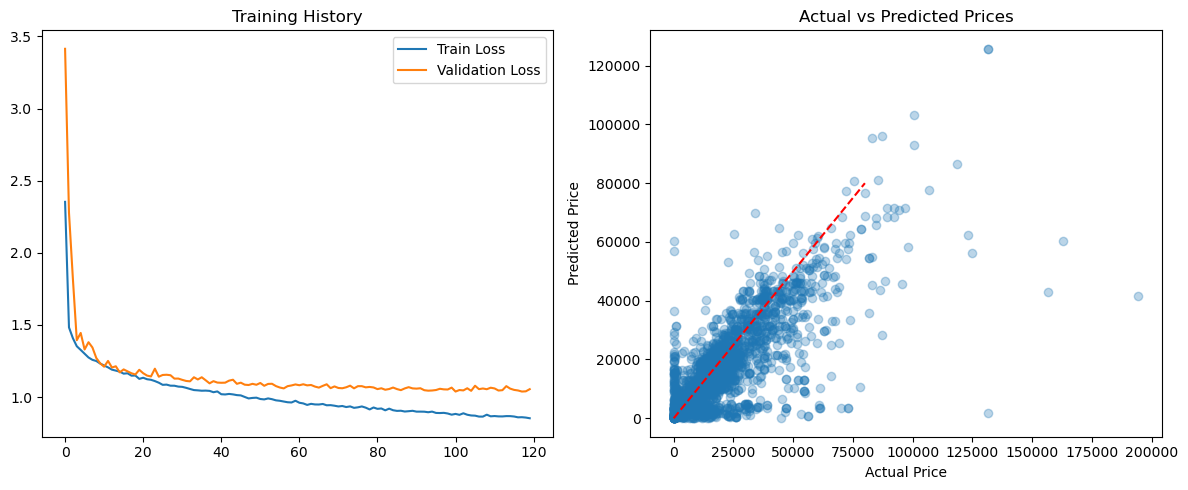

In [19]:
# 训练过程可视化
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training History')
plt.legend()

# 预测结果可视化
plt.subplot(1, 2, 2)
plt.scatter(np.expm1(y_test), np.expm1(mlp.predict(X_test_processed)), alpha=0.3)
plt.plot([0, 80000], [0, 80000], '--r')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Prices')
plt.tight_layout()
plt.show()